In [1]:
%cd ..

/home/dev/workspace


# Iterative inference on single batches

Probes the `IterativeGuide` + `AutoMeanFieldProposal` inference algorithm from
the `marionette_captcha` experiment on one batch at a time, without running the
full trainer: how far the inner `optimistix` solve moves the guide, what it
costs, and what the adapted posterior looks like.

Knobs live in the `overrides` list below. Everything here runs **eagerly** (no
jit), so it is usable locally at small settings; on the pod, raise
`data.batch_size`, `guide.max_steps`, and the particle counts.

In [2]:
import functools
import os
import time

import hydra
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from numpyro.handlers import block, seed, substitute, trace
from omegaconf import OmegaConf
import optimistix
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

PosixPath('/home/dev/workspace')

In [4]:
overrides = [
    "+experiment=marionette_captcha",
    "data.batch_size=4",              # pod: 32
    "guide.max_steps=100",            # inner-solve budget; pod: 100+
    "guide.tracer.num_particles=4",   # pod: 4
    "learner.tracer.num_particles=4", # pod: 4
    "+model.scale=0.1",
]

with hydra.initialize_config_dir(version_base="1.3",
                                 config_dir=os.getcwd() + "/configs"):
    cfg = hydra.compose(config_name="train", overrides=overrides)

datamodule = hydra.utils.instantiate(cfg.data)
model = hydra.utils.instantiate(cfg.model)
guide = hydra.utils.instantiate(cfg.guide)
learner = hydra.utils.instantiate(cfg.learner, data_shape=datamodule.shape,
                                  guide=guide, model=model)
learner.setup_step(datamodule)
guide = learner.guide

E0721 19:49:03.599046   18077 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [5]:
# Optional: load model parameters from a training checkpoint instead of a
# fresh initialization.
# from src.utils import unserialize_key
# checkpoint = np.load("logs/train/runs/<run>/saved/checkpoint-epoch<N>.npy",
#                      allow_pickle=True).item()
# learner.load(jax.tree.map_with_path(unserialize_key, checkpoint))

In [6]:
# Record every inner solve's Solution so we can read off step counts and
# convergence results. (Eager-only instrumentation -- do not jit around this.)
solutions = []
if not getattr(optimistix.minimise, "_is_spy", False):
    _orig_minimise = optimistix.minimise
    def _spy(*args, **kwargs):
        solution = _orig_minimise(*args, **kwargs)
        solutions.append(solution)
        return solution
    _spy._is_spy = True
    optimistix.minimise = _spy

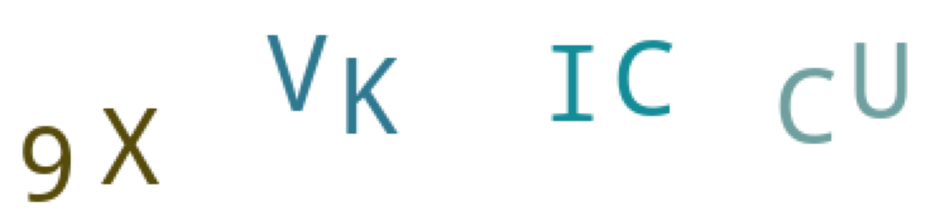

In [7]:
data = next(iter(datamodule.valid_dataloader()))[0]

fig, axes = plt.subplots(1, data.shape[0], figsize=(3 * data.shape[0], 3))
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(data[i])
    ax.set_axis_off()

## One adaptation, timed

Run the inner solve once on this batch and see how many steps it takes, whether
it hits the budget or the tolerance, and how far each variational parameter
moves from its prior-mirror initialization.

In [8]:
t0 = time.time()
with seed(rng_seed=0), substitute(data=learner.parameters):
    adapted = jax.block_until_ready(guide.adapt(data))
wall = time.time() - t0

solution = solutions[-1]
print(f"{int(solution.stats['num_steps'])} inner steps "
      f"(result: {solution.result}) in {wall:.1f}s")

100 inner steps (result: optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>) in 10.9s


In [9]:
with seed(rng_seed=0):
    with block(hide_fn=lambda msg: msg["type"] == "param"):
        init_trace = trace(guide.guide).get_trace(data)
init = {name: site["value"] for name, site in init_trace.items()
        if site["type"] == "param"}

for name, value in adapted.items():
    delta = np.abs(np.asarray(value) - np.asarray(init[name]))
    print(f"{name}: shape {value.shape} max|d| {delta.max():.4g} "
          f"mean|d| {delta.mean():.4g}")

color_auto_concentration0: shape (4, 3) max|d| 3.83 mean|d| 2.435
color_auto_concentration1: shape (4, 3) max|d| 3.154 mean|d| 2.217
z_mark_auto_logits: shape (4, 43, 55, 36) max|d| 7.596 mean|d| 0.3091
z_mark_auto_temperature: shape (4, 43, 55) max|d| 2.672 mean|d| 0.6678
z_switch_auto_logits: shape (4, 43, 55) max|d| 6.143 mean|d| 0.6111
z_switch_auto_temperature: shape (4, 43, 55) max|d| 4.482 mean|d| 0.5899


## Does adaptation help the outer objective?

Score the full outer ELBO (via the learner's `AdaptiveElboTracer`) with the
same noise, once with the fresh prior-mirror guide and once with per-batch
adaptation. `functools.partial(guide, adaptation=None)` hides the `adapt`
method, so the tracer skips adaptation for the baseline.

In [10]:
def outer_metrics(g, key=1):
    loss, state = learner.tracer.loss(random.key(key), learner.parameters, {},
                                      learner.model, g, data)
    metrics, _ = learner._step_telemetry(loss, state)
    return {k: float(v) for k, v in metrics.items()
            if k in ("loss", "nll", "kl", "ess", "log_w")}

fresh = outer_metrics(functools.partial(guide, adaptation=None))
adapted_metrics = outer_metrics(guide)
print(f"{'':>10} {'fresh':>14} {'adapted':>14}")
for k in fresh:
    print(f"{k:>10} {fresh[k]:>14.4g} {adapted_metrics[k]:>14.4g}")

                    fresh        adapted
      loss     -5.606e+04     -2.718e+04
     log_w      5.606e+04      2.718e+04
       nll     -1.402e+04     -1.932e+04
        kl              0      1.252e+04
       ess           0.25           0.25


## Reconstructions, switch maps, and a template-matching oracle

Left to right: data, posterior-mean reconstruction, the adapted `z_switch`
activation map, and where switches *ought* to fire by pure template matching --
each glyph's support mask correlated with the image's ink (the correlation is
the adjoint of the model's `conv_transpose` render, so it lives on exactly the
same anchor grid), normalized per glyph and maxed over the dictionary.

/home/dev/workspace/src/inference/tracer.py:371: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


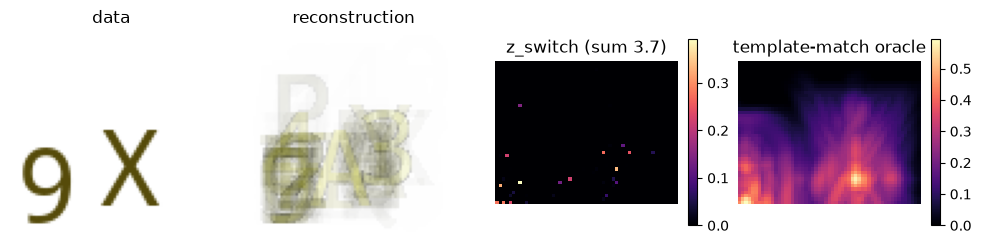

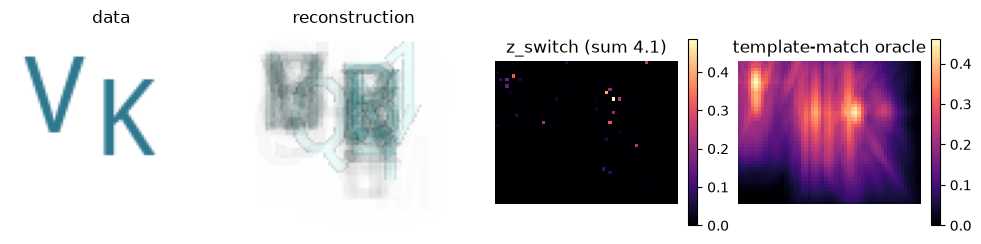

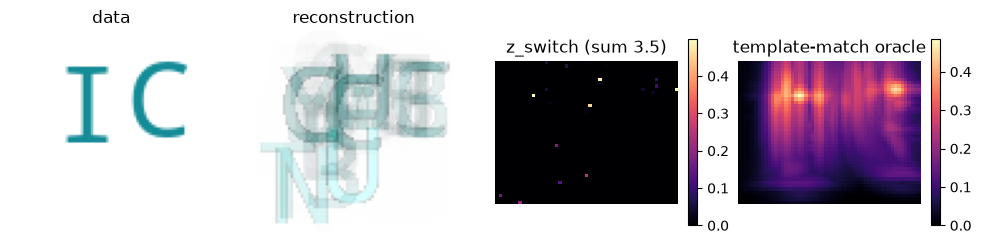

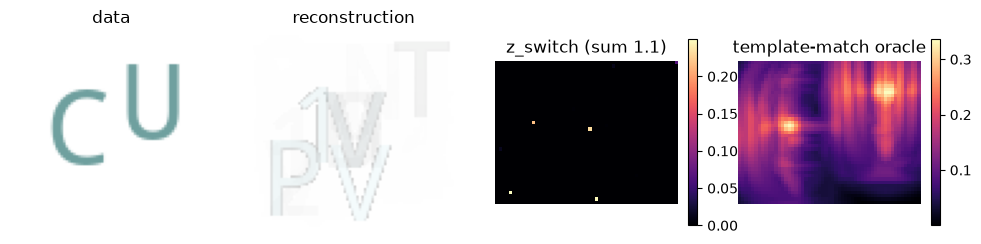

In [11]:
from src.model.model import _dictionary_support_masks

placements = model.keywords["placements"]
masks = _dictionary_support_masks(placements.shape_dict.shapes)  # (K, kh, kw, 1)
ink = 1. - jnp.asarray(data).mean(axis=-1, keepdims=True)        # (B, H, W, 1)

def correlate_one(mask):
    kernel = (mask / mask.sum())[..., jnp.newaxis]               # (kh, kw, 1, 1)
    return jax.lax.conv_general_dilated(
        ink, kernel, window_strides=(placements.stride,) * 2, padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )[..., 0]                                                    # (B, out_h, out_w)

# Mean ink under each glyph's support at every anchor, maxed over glyphs.
oracle = jax.vmap(correlate_one)(masks).max(axis=0)

samples, predictions = learner(data, stage="valid")
recon = predictions["obs"]["ev"].mean(axis=0)
switches = predictions["z_switch"]["value"].mean(axis=0)
for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    axes[0].imshow(data[i])
    axes[0].set_title("data")
    axes[1].imshow(np.clip(recon[i], 0., 1.))
    axes[1].set_title("reconstruction")
    im = axes[2].imshow(switches[i], cmap="magma")
    axes[2].set_title(f"z_switch (sum {switches[i].sum():.1f})")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    im = axes[3].imshow(oracle[i], cmap="magma")
    axes[3].set_title("template-match oracle")
    fig.colorbar(im, ax=axes[3], fraction=0.046)
    for ax in axes:
        ax.set_axis_off()

## Why does the NLL plateau while reconstructions underfit?

Two mechanisms to check, both visible from the adapted point:

1. **Saturated (dead) switches.** The reparameterized sample is
   `sigmoid((logits + noise) / temperature)`, so an anchor whose fixed noise
   draws all land deep in the off-region has `d(sample)/d(logits) ~ 0`: the
   reconstruction gradient cannot reach it, no matter how much ink the oracle
   says it covers. With the prior's switch logit around -6, that is *most*
   anchors -- only noise-lucky ones are trainable, they converge within a few
   dozen steps, and the NLL flattens there.
2. **Travel distance vs the Adam step.** Adam moves each coordinate by at most
   ~lr per step; a dead switch needs its logit to travel ~6-12 to activate.
   At lr 0.1 that is >=60-120 steps *if* it gets gradient at all, and the
   decaying schedule caps total travel at ~sum(lr) ~ 20.

The cell below evaluates the inner (reconstruction) objective's gradient at
the adapted parameters and compares dead vs live anchors.

anchors saturated off across all particles: 97.9%
mean |grad wrt switch logits| -- dead: 0.37, live: 0.631
switch logit travel available: prior logit -7.77, max adapted -1.63


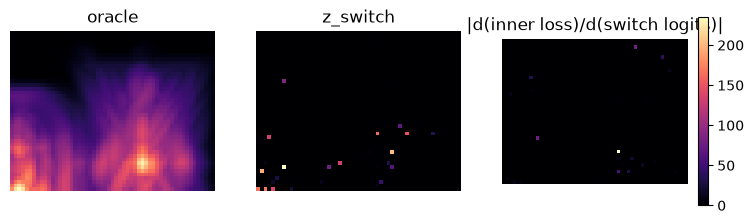

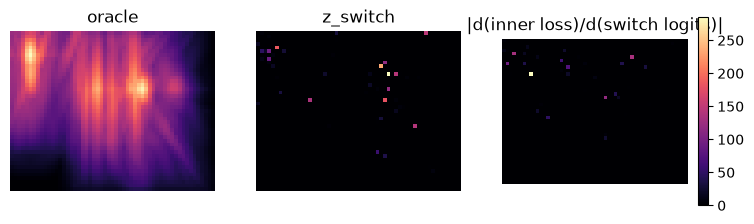

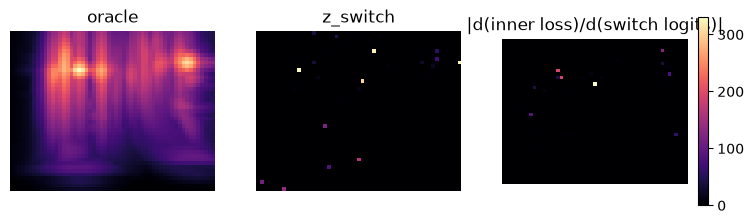

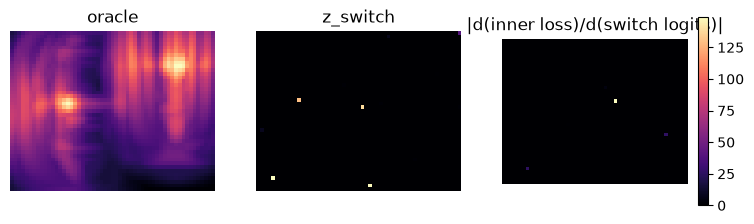

In [12]:
buffers = jax.lax.stop_gradient(dict(learner.parameters))

def inner_objective(params, key=0):
    return guide.tracer.loss(random.key(key), {**params, **buffers}, {},
                             learner.model, guide.guide, data)[0]

grads = jax.grad(inner_objective)(adapted)
switch_grad = np.abs(np.asarray(grads["z_switch_auto_logits"]))

z_samples = np.asarray(predictions["z_switch"]["value"])  # (particles, B, H, W)
dead = (z_samples < 1e-3).all(axis=0)
print(f"anchors saturated off across all particles: {dead.mean():.1%}")
print(f"mean |grad wrt switch logits| -- dead: {switch_grad[dead].mean():.3g}, "
      f"live: {switch_grad[~dead].mean():.3g}")
print(f"switch logit travel available: prior logit "
      f"{float(init['z_switch_auto_logits'].mean()):.2f}, "
      f"max adapted {float(np.asarray(adapted['z_switch_auto_logits']).max()):.2f}")

for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(oracle[i], cmap="magma")
    axes[0].set_title("oracle")
    axes[1].imshow(switches[i], cmap="magma")
    axes[1].set_title("z_switch")
    im = axes[2].imshow(switch_grad[i], cmap="magma")
    axes[2].set_title("|d(inner loss)/d(switch logits)|")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    for ax in axes:
        ax.set_axis_off()

## How much inner budget does this batch need?

Outer metrics as a function of `max_steps`. Each point re-runs the full inner
solve eagerly, so this cell costs minutes locally -- it is meant for the pod,
where the per-evaluation cost is small.

max_steps 5: {'loss': -35348.0703125, 'log_w': 35348.0703125, 'nll': -15458.4873046875, 'kl': 6621.4697265625, 'ess': 0.25}
max_steps 10: {'loss': -25068.03515625, 'log_w': 25068.03515625, 'nll': -16077.787109375, 'kl': 9810.77734375, 'ess': 0.25}
max_steps 25: {'loss': -19860.7109375, 'log_w': 19860.7109375, 'nll': -17947.25390625, 'kl': 12982.076171875, 'ess': 0.25}
max_steps 50: {'loss': -21885.44921875, 'log_w': 21885.44921875, 'nll': -19207.8671875, 'kl': 13736.505859375, 'ess': 0.25}
max_steps 100: {'loss': -23061.20703125, 'log_w': 23061.20703125, 'nll': -19551.73828125, 'kl': 13786.4375, 'ess': 0.25}
max_steps 200: {'loss': -22638.322265625, 'log_w': 22638.322265625, 'nll': -19414.943359375, 'kl': 13755.3623046875, 'ess': 0.25}


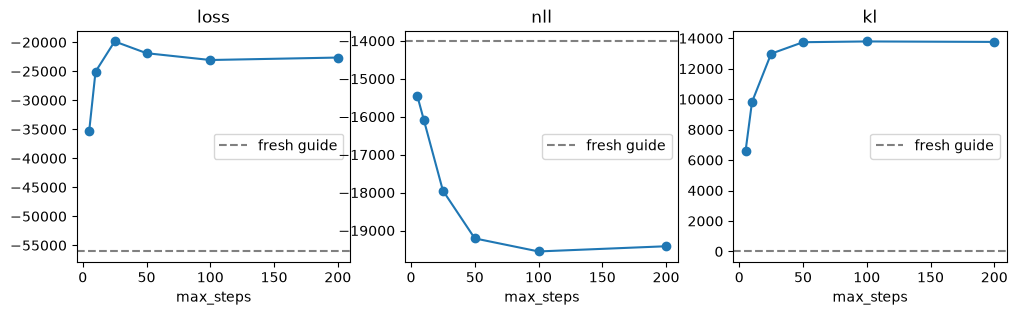

In [13]:
budgets = [5, 10, 25, 50, 100, 200]  # pod: extend to 100, 200, ...
rows = []
for budget in budgets:
    budget_guide = hydra.utils.instantiate(cfg.guide,
                                           max_steps=budget)(learner.model)
    metrics = outer_metrics(budget_guide)
    rows.append(metrics)
    print(f"max_steps {budget}: {metrics}", flush=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, key in zip(axes, ("loss", "nll", "kl")):
    ax.plot(budgets, [r[key] for r in rows], marker="o")
    ax.axhline(fresh[key], color="grey", linestyle="--", label="fresh guide")
    ax.set_xlabel("max_steps")
    ax.set_title(key)
    ax.legend()

In [14]:
fast_guide = hydra.utils.instantiate(
    cfg.guide, max_steps=300,
    solver={"optim": {"learning_rate": {"init_value": 0.5,
                                        "transition_steps": 300}}},
)(learner.model)
print(outer_metrics(fast_guide))

{'loss': 2064926.375, 'log_w': -2064926.5, 'nll': -20444.150390625, 'kl': 536675.75, 'ess': 0.25}


In [15]:
loss, state = learner.tracer.loss(random.key(1), learner.parameters, {},
                                  learner.model, fast_guide, data)
for name, site in state["trace"].items():
    gap = float((site["log_q"] - site["log_p"]).mean(axis=0).sum())
    print(f"{name}: {gap:.4g}")

color: 102.8
obs: -8.302e+04
residual: 0
z_mark: -3.444e+05
z_switch: 2.413e+06
